# Week 2 — End-to-End ML Pipeline on Sales/Price Data

**Name:** Bhavya Jain  
**Dataset:** `tesla_deliveries_dataset_2015_2025.csv`

## Assignment objective

The target of this notebook is to predict `Estimated_Deliveries`. The dataset is first explored through EDA, followed by the creation of relevant time-based features. Linear Regression and Random Forest models are then trained and compared using suitable evaluation metrics. Since the dataset contains year and month information, the records are kept in chronological order during the train-test split.

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller

pd.set_option("display.max_columns", None)

## 2. Load and inspect the dataset

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Shape: (2640, 12)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Year,2640.0,NaN,NaN,NaN,2020.0,3.162877,2015.0,2017.0,2020.0,2023.0,2025.0
Month,2640.0,NaN,NaN,NaN,6.5,3.452707,1.0,3.75,6.5,9.25,12.0
Region,2640,4,Europe,660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Model,2640,5,Model S,528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Deliveries,2640.0,NaN,NaN,NaN,9922.199621,3935.950093,48.0,7292.0,9857.0,12510.25,25704.0
Production_Units,2640.0,NaN,NaN,NaN,10655.847348,4260.600858,50.0,7828.25,10546.5,13469.0,28939.0
Avg_Price_USD,2640.0,NaN,NaN,NaN,84907.34033,20123.258036,50003.7,67726.365,85058.51,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,NaN,NaN,NaN,87.05947,20.836265,60.0,75.0,82.0,100.0,120.0
Range_km,2640.0,NaN,NaN,NaN,500.257576,120.868549,330.0,418.0,470.0,586.25,719.0
CO2_Saved_tons,2640.0,NaN,NaN,NaN,744.076989,353.221224,3.07,499.62,699.515,943.765,2548.55


### What the dataset contains

The file has 2,640 rows and 12 original columns. It contains time information, Tesla model and region details, production and delivery figures, vehicle specifications, price, source type, and charging-station data. `Estimated_Deliveries` is the value that the models will predict.

## 3. Check missing values and duplicate rows

In [3]:
print("Missing values:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)

# Create a date column and arrange the rows in time order
df["Date"] = pd.to_datetime(
    dict(year=df["Year"], month=df["Month"], day=1)
)

df = df.sort_values(
    ["Date", "Region", "Model"]
).reset_index(drop=True)

print("\nFirst and last dates:")
print(df["Date"].min(), "to", df["Date"].max())

Missing values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate rows: 0

First and last dates:
2015-01-01 00:00:00 to 2025-12-01 00:00:00


### Data-quality observation

There are no missing values and no duplicate rows in the source data. This means I do not need to delete or impute any original records. I still performed these checks because missing or repeated records could affect charts, rolling features, and model results.

## 4. Exploratory Data Analysis

### 4.1 Estimated deliveries by model

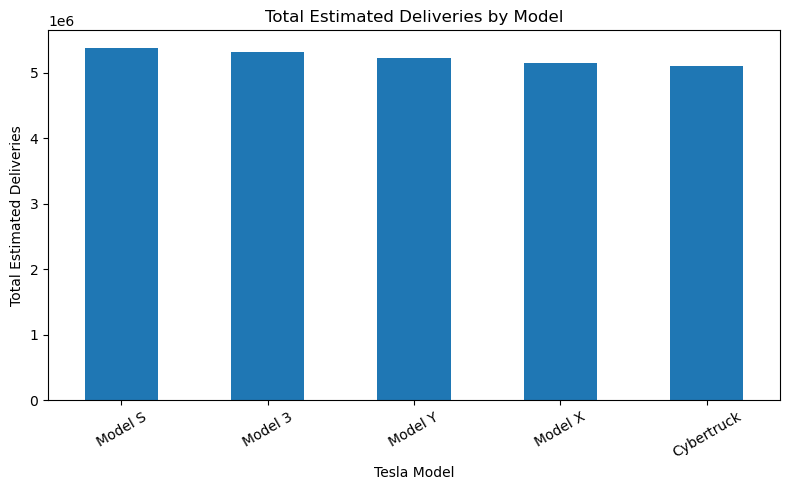

In [4]:
model_deliveries = (
    df.groupby("Model")["Estimated_Deliveries"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
model_deliveries.plot(kind="bar")
plt.title("Total Estimated Deliveries by Model")
plt.xlabel("Tesla Model")
plt.ylabel("Total Estimated Deliveries")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Observation from the model chart

This chart compares the total estimated deliveries of the different Tesla models. It helps identify which models contribute more to the overall delivery volume. The totals should still be interpreted with care because the records also differ by year and region.

### 4.2 Estimated deliveries by region

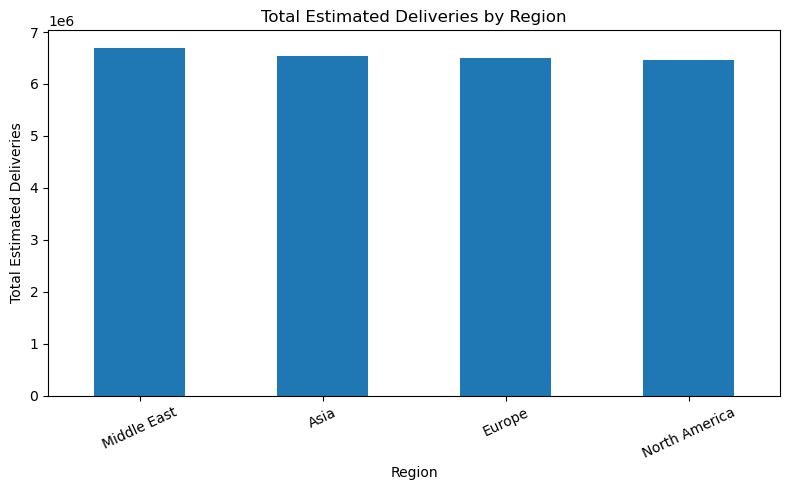

In [5]:
region_deliveries = (
    df.groupby("Region")["Estimated_Deliveries"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
region_deliveries.plot(kind="bar")
plt.title("Total Estimated Deliveries by Region")
plt.xlabel("Region")
plt.ylabel("Total Estimated Deliveries")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### Observation from the region chart

The regional chart shows how delivery volume is distributed across the four regions in the dataset. Differences may be related to demand, production allocation, infrastructure, or the number of observations represented for each region.

### 4.3 Correlation heatmap

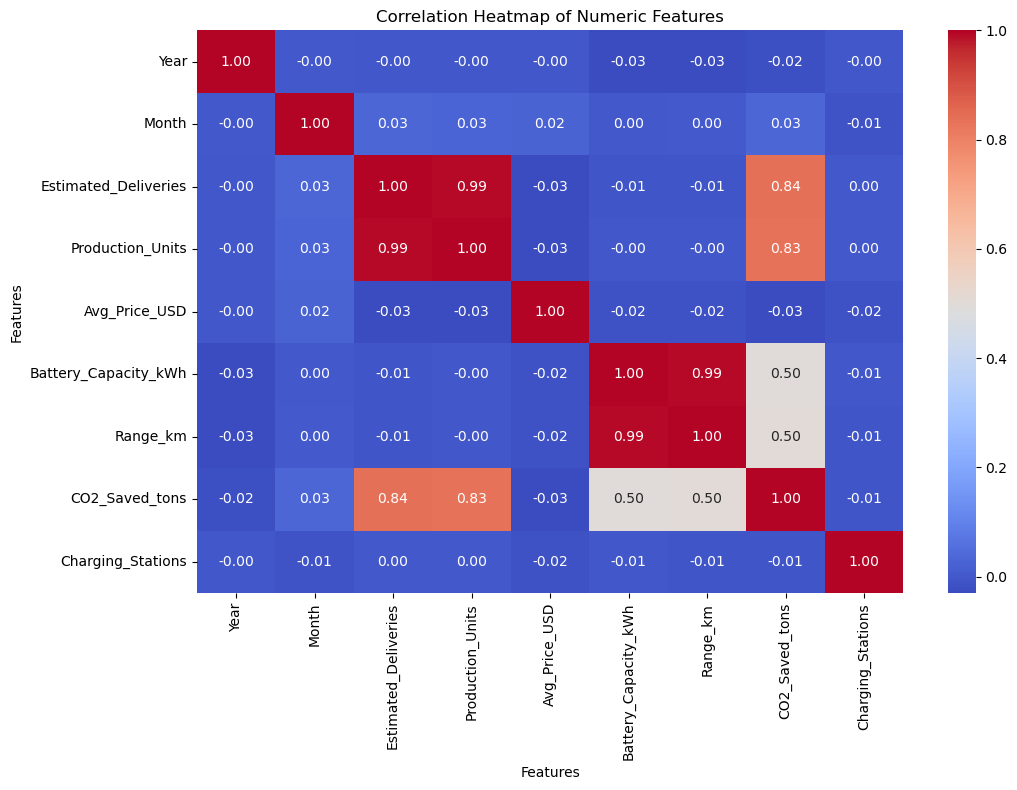

Correlation between Production_Units and Estimated_Deliveries: 0.9942


In [6]:
numeric_data = df.select_dtypes(include=np.number)
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Numeric Features")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

production_delivery_corr = correlation_matrix.loc[
    "Production_Units", "Estimated_Deliveries"
]

print(
    "Correlation between Production_Units and Estimated_Deliveries:",
    round(production_delivery_corr, 4)
)

### Correlation interpretation

`Production_Units` and `Estimated_Deliveries` have a correlation of about 0.99, which is a very strong positive relationship. This means larger production values are generally associated with larger delivery values. However, correlation alone does not prove that one variable is the only cause of the other.

### 4.4 Production vs deliveries scatter plot

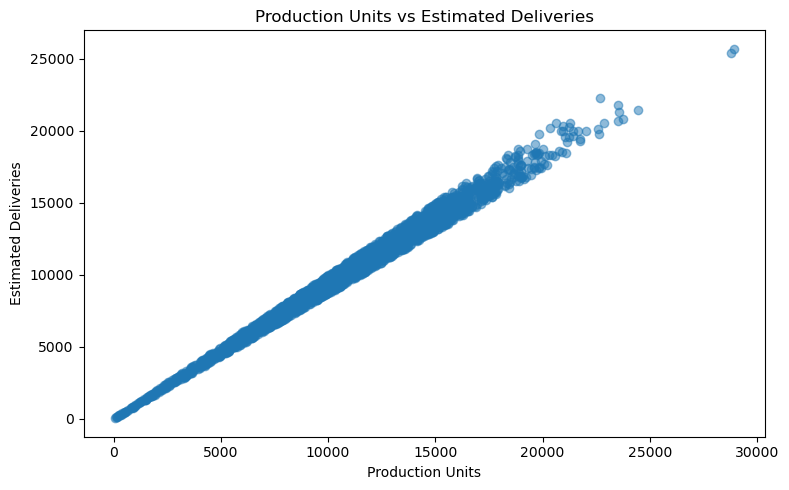

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df["Production_Units"],
    df["Estimated_Deliveries"],
    alpha=0.5
)

plt.title("Production Units vs Estimated Deliveries")
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")
plt.tight_layout()
plt.show()

### Scatter-plot observation

The points form a clear upward pattern, which supports the strong positive correlation found earlier. Most points lie close to a straight trend, but some spread remains because delivery values can also be influenced by model, region, price, infrastructure, and time.

### 4.5 Monthly time-trend line plot

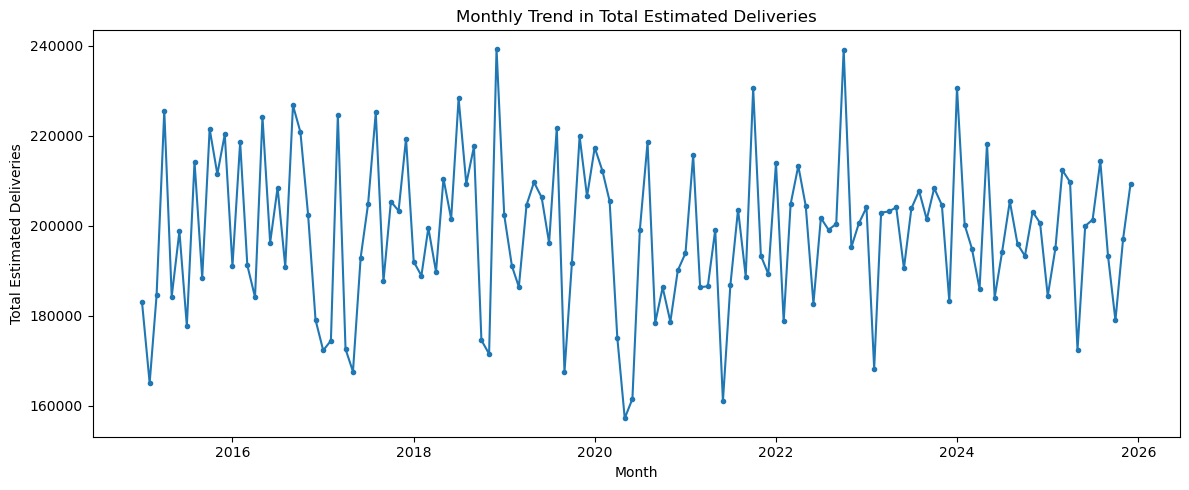

In [8]:
monthly_deliveries = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
      .sort_index()
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_deliveries.index,
    monthly_deliveries.values,
    marker="o",
    markersize=3
)

plt.title("Monthly Trend in Total Estimated Deliveries")
plt.xlabel("Month")
plt.ylabel("Total Estimated Deliveries")
plt.tight_layout()
plt.show()

### Time-trend observation

The line plot keeps the observations in chronological order and shows how total monthly deliveries change from 2015 to 2025. It is useful for noticing growth, drops, and fluctuations over time. Since the line combines all models and regions, it represents the overall monthly pattern.

## 5. Encoding and feature engineering

In [9]:
categorical_columns = ["Region", "Model", "Source_Type"]
encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    encoded_column = column + "_Encoded"

    df[encoded_column] = encoder.fit_transform(df[column])
    encoders[column] = encoder

    print(column, "mapping:")
    print(
        dict(
            zip(
                encoder.classes_,
                encoder.transform(encoder.classes_)
            )
        )
    )
    print()

# Previous record's delivery value
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)

# Mean of the previous three delivery records
# shift(1) prevents the current target value from entering its own feature
df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
      .shift(1)
      .rolling(window=3)
      .mean()
)

df["Deliveries_Lag1"] = df["Deliveries_Lag1"].fillna(
    df["Deliveries_Lag1"].mean()
)

df["Rolling_Mean_3"] = df["Rolling_Mean_3"].fillna(
    df["Rolling_Mean_3"].mean()
)

print("Remaining missing values:")
print(
    df[["Deliveries_Lag1", "Rolling_Mean_3"]]
      .isnull()
      .sum()
)

display(
    df[
        [
            "Estimated_Deliveries",
            "Deliveries_Lag1",
            "Rolling_Mean_3"
        ]
    ].head()
)

Region mapping:
{'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}

Model mapping:
{'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}

Source_Type mapping:
{'Estimated (Region)': np.int64(0), 'Interpolated (Month)': np.int64(1), 'Official (Quarter)': np.int64(2)}

Remaining missing values:
Deliveries_Lag1    0
Rolling_Mean_3     0
dtype: int64


,Estimated_Deliveries,Deliveries_Lag1,Rolling_Mean_3
0,11325,9922.979159,9923.690431
1,8795,11325.000000,9923.690431
2,9537,8795.000000,9923.690431
3,7292,9537.000000,9885.666667
4,12446,7292.000000,8541.333333


### Why these features were created

`LabelEncoder` changes the text categories into numeric codes so that the models can use them. These codes represent categories and should not be treated as meaningful ranks. `Deliveries_Lag1` provides the previous delivery value, while `Rolling_Mean_3` gives a short recent average. I shifted the target before calculating the rolling mean so that the current value is not used to predict itself.

## 6. Chronological split and Linear Regression

Training rows: 2112
Testing rows: 528
Training percentage: 80.0
Testing percentage: 20.0

Linear Regression results
MAE: 322.8746
RMSE: 392.5701
R²: 0.9885


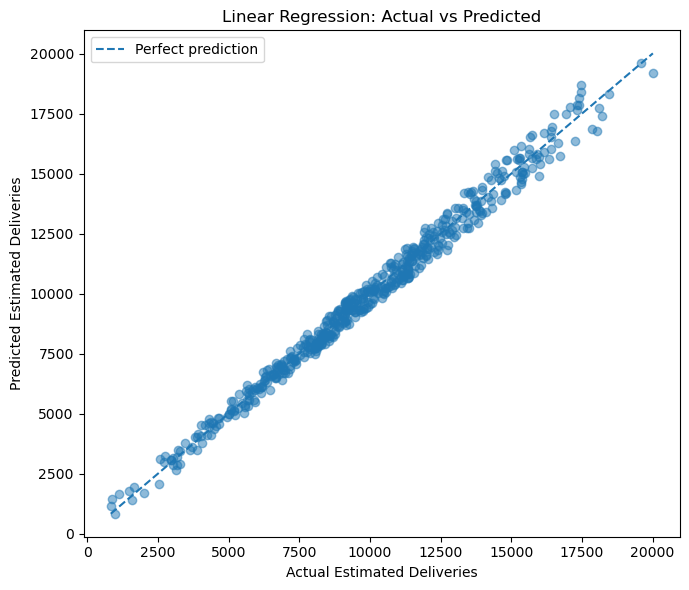

In [10]:
feature_columns = [
    "Year",
    "Month",
    "Region_Encoded",
    "Model_Encoded",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Source_Type_Encoded",
    "Charging_Stations",
    "Deliveries_Lag1",
    "Rolling_Mean_3"
]

X = df[feature_columns]
y = df["Estimated_Deliveries"]

split_index = int(len(df) * 0.80)

# Chronological index slicing
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training percentage:", round(len(X_train) / len(df) * 100, 2))
print("Testing percentage:", round(len(X_test) / len(df) * 100, 2))

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)
linear_r2 = r2_score(y_test, linear_predictions)

print("\nLinear Regression results")
print("MAE:", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²:", round(linear_r2, 4))

plt.figure(figsize=(7, 6))
plt.scatter(y_test, linear_predictions, alpha=0.5)

minimum_value = min(y_test.min(), linear_predictions.min())
maximum_value = max(y_test.max(), linear_predictions.max())

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    label="Perfect prediction"
)

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Estimated Deliveries")
plt.ylabel("Predicted Estimated Deliveries")
plt.legend()
plt.tight_layout()
plt.show()

### Linear Regression interpretation

The split uses the first 80% of the ordered rows for training and the last 20% for testing, instead of randomly mixing past and future records. MAE shows the average absolute error, RMSE gives more penalty to large errors, and R² shows how much of the variation in the test target is explained by the model. The points close to the diagonal line represent accurate predictions.

## 7. Cross-validation and Random Forest tuning

In [11]:
# Five-Fold Cross-Validation
kfold = KFold(
    n_splits=5,
    shuffle=False
)

cv_scores = cross_val_score(
    LinearRegression(),
    X_train,
    y_train,
    cv=kfold,
    scoring="r2"
)

print("Linear Regression R² for each fold:")
for fold_number, score in enumerate(cv_scores, start=1):
    print("Fold", fold_number, ":", round(score, 4))

print("Mean R²:", round(cv_scores.mean(), 4))
print("Standard deviation:", round(cv_scores.std(), 4))

Linear Regression R² for each fold:
Fold 1 : 0.9895
Fold 2 : 0.9911
Fold 3 : 0.9901
Fold 4 : 0.9913
Fold 5 : 0.991
Mean R²: 0.9906
Standard deviation: 0.0007


Best parameters: {'max_depth': None, 'n_estimators': 100}
Best cross-validation R²: 0.9905

Random Forest results
MAE: 260.8361
RMSE: 327.8138
R²: 0.992


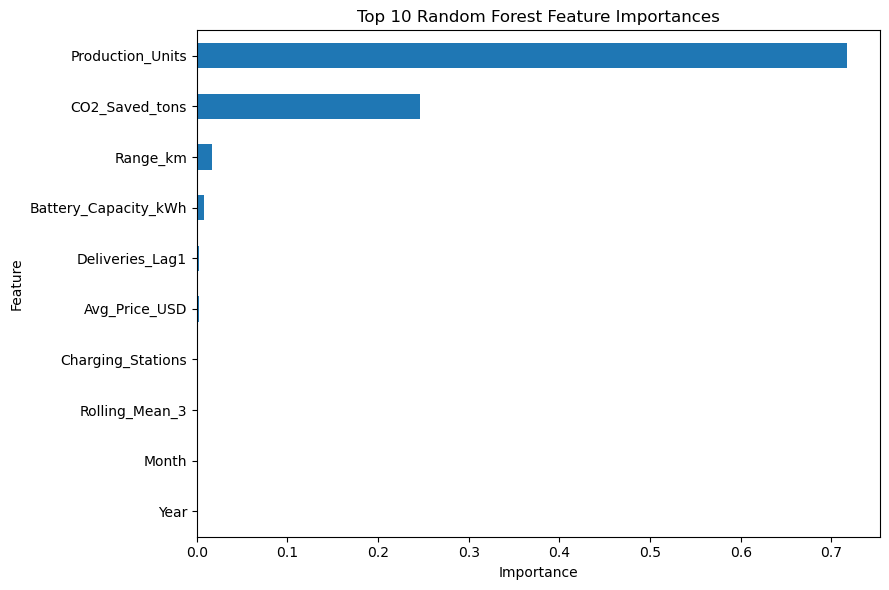

,Importance
Production_Units,0.717644
CO2_Saved_tons,0.245862
Range_km,0.016370
Battery_Capacity_kWh,0.008404
Deliveries_Lag1,0.002669
Avg_Price_USD,0.002376
Charging_Stations,0.001895
Rolling_Mean_3,0.001595
Month,0.001211
Year,0.000632


In [12]:
random_forest = RandomForestRegressor(
    random_state=42,
    max_features=0.6
)

parameter_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=parameter_grid,
    cv=5,
    scoring="r2",
    n_jobs=1
)

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_
rf_predictions = best_rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)
rf_r2 = r2_score(y_test, rf_predictions)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation R²:", round(grid_search.best_score_, 4))

print("\nRandom Forest results")
print("MAE:", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²:", round(rf_r2, 4))

feature_importance = pd.Series(
    best_rf_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

top_10_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(9, 6))
top_10_features.plot(kind="barh")
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(
    feature_importance.head(10).to_frame("Importance")
)

### Cross-validation and Random Forest interpretation

The five R² scores show whether Linear Regression performs consistently across different folds, while the mean and standard deviation summarise the overall result. GridSearchCV checks all required combinations of `n_estimators` and `max_depth` and selects the combination with the best validation score. I kept `max_features=0.6` fixed so that different trees can consider different subsets of predictors. In a real forecasting project, I would also compare this K-Fold result with `TimeSeriesSplit`, because normal K-Fold does not fully preserve the past-to-future validation pattern.

## 8. Stationarity test, Forecast table, and Model comparison

In [13]:
adf_result = adfuller(
    df["Estimated_Deliveries"]
)

adf_statistic = adf_result[0]
adf_p_value = adf_result[1]
critical_values = adf_result[4]

print("ADF statistic:", round(adf_statistic, 4))
print("p-value:", adf_p_value)

print("\nCritical values:")
for level, value in critical_values.items():
    print(level, ":", round(value, 4))

if adf_p_value < 0.05:
    print(
        "\nConclusion: Reject the null hypothesis. "
        "Estimated_Deliveries is stationary at the 5% level."
    )
else:
    print(
        "\nConclusion: Fail to reject the null hypothesis. "
        "Estimated_Deliveries is non-stationary at the 5% level."
    )

ADF statistic: -49.3647
p-value: 0.0

Critical values:
1% : -3.4328
5% : -2.8626
10% : -2.5674

Conclusion: Reject the null hypothesis. Estimated_Deliveries is stationary at the 5% level.


In [14]:
forecast_table = pd.DataFrame({
    "Actual": y_test.iloc[:20].values,
    "Predicted": rf_predictions[:20]
})

forecast_table["Absolute_Error"] = (
    forecast_table["Actual"]
    - forecast_table["Predicted"]
).abs()

forecast_table["Error_Percent"] = (
    forecast_table["Absolute_Error"]
    / forecast_table["Actual"]
    * 100
)

print("First 20 Random Forest predictions:")
display(forecast_table.round(2))

First 20 Random Forest predictions:


,Actual,Predicted,Absolute_Error,Error_Percent
0,8179,8559.49,380.49,4.65
1,4490,4491.10,1.10,0.02
2,14734,14855.00,121.00,0.82
3,11110,10680.72,429.28,3.86
4,11636,11601.71,34.29,0.29
5,10819,10646.43,172.57,1.60
6,14430,15053.69,623.69,4.32
7,12266,11830.10,435.90,3.55
8,8624,8824.19,200.19,2.32
9,5019,4990.11,28.89,0.58


In [15]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R²": [
        linear_r2,
        rf_r2
    ]
})

print("Model comparison:")
display(
    model_comparison.round(4)
)

Model comparison:


,Model,MAE,RMSE,R²
0,Linear Regression,322.8746,392.5701,0.9885
1,Random Forest,260.8361,327.8138,0.9920


### Final interpretation

The ADF test uses the null hypothesis that the series has a unit root and is non-stationary. Since the p-value is below 0.05, the null hypothesis is rejected for this ordered delivery series. The forecast table shows the actual value, Random Forest prediction, absolute error, and percentage error for the first 20 test records. The final table makes it easy to compare both models using MAE, RMSE, and R²; in this dataset, the tuned Random Forest gives the stronger test result.